# 01 — EDA: Training Signals



In [8]:
from sys import path

import pandas as pd

sessions = pd.read_parquet('../data/sessions.parquet')
records = pd.read_parquet('../data/records.parquet')
daily = pd.read_parquet('../data/daily_signals.parquet')

print(sessions.shape, records.shape, daily.shape)

(38, 22) (83459, 16) (54, 20)


In [12]:
import pandas as pd
import os

path = r"C:\Users\vasiu\UBB\Quantified-Strides\data"

for f in ['sessions.parquet', 'records.parquet', 'daily_signals.parquet']:
    df = pd.read_parquet(os.path.join(path, f))
    print(df.shape)
    print(df.dtypes)

(38, 22)
sport                       object
start_time          datetime64[ns]
date                datetime64[ns]
duration_s                 float64
distance_m                 float64
total_ascent               float64
total_descent              float64
avg_hr                       int64
max_hr                       int64
calories                     int64
avg_cadence                float64
avg_power                  float64
norm_power                 float64
avg_vo                     float64
avg_stance                 float64
avg_step_len               float64
avg_vr                     float64
training_effect            float64
anaerobic_effect           float64
session_id                   int64
n_records                    int64
trimp                      float64
dtype: object
(83459, 16)
session_id                       int64
timestamp               datetime64[ns]
heart_rate                       int64
speed_ms                       float64
pace_min_km                    float64


In [10]:
from fitparse import FitFile

fit = FitFile(r"C:\Users\vasiu\DI_CONNECT\DI-Connect-Uploaded-Files\vasiuvlad984@gmail.com_301121492539.fit")
fields = set()
for record in fit.get_messages('record'):
    for field in record.fields:
        fields.add(field.name)

print(sorted(fields))


['accumulated_power', 'activity_type', 'cadence', 'distance', 'enhanced_altitude', 'enhanced_speed', 'fractional_cadence', 'heart_rate', 'position_lat', 'position_long', 'power', 'stance_time', 'stance_time_balance', 'stance_time_percent', 'step_length', 'timestamp', 'unknown_107', 'unknown_134', 'unknown_135', 'unknown_136', 'unknown_140', 'unknown_143', 'unknown_87', 'unknown_90', 'vertical_oscillation', 'vertical_ratio']


Let's start looking at the actual data per workout

In [15]:
sessions = pd.read_parquet('../data/sessions.parquet')

sessions.info(
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   sport             38 non-null     object        
 1   start_time        38 non-null     datetime64[ns]
 2   date              38 non-null     datetime64[ns]
 3   duration_s        38 non-null     float64       
 4   distance_m        38 non-null     float64       
 5   total_ascent      38 non-null     float64       
 6   total_descent     38 non-null     float64       
 7   avg_hr            38 non-null     int64         
 8   max_hr            38 non-null     int64         
 9   calories          38 non-null     int64         
 10  avg_cadence       7 non-null      float64       
 11  avg_power         10 non-null     float64       
 12  norm_power        10 non-null     float64       
 13  avg_vo            5 non-null      float64       
 14  avg_stance        5 non-null

Let's look at running data specifically

In [16]:
runs = sessions[sessions['sport'] == 'running']

runs

,sport,start_time,date,duration_s,distance_m,total_ascent,total_descent,avg_hr,max_hr,calories,...,norm_power,avg_vo,avg_stance,avg_step_len,avg_vr,training_effect,anaerobic_effect,session_id,n_records,trimp
11,running,2026-03-10 13:33:10,2026-03-10,665.683,1646.14,41.0,39.0,173,191,170,...,372.0,87.2,298.9,954.0,9.27,2.4,0.0,34,667,39.116667
16,running,2026-03-18 13:16:23,2026-03-18,843.141,2147.47,52.0,48.0,180,195,216,...,380.0,88.8,297.9,980.0,9.18,2.7,0.0,17,844,51.250000
20,running,2026-03-23 15:17:56,2026-03-23,2190.080,3813.86,49.0,55.0,161,198,348,...,361.0,88.5,294.0,1044.2,8.54,3.1,0.2,20,1455,69.558333
30,running,2026-04-07 16:33:03,2026-04-07,2111.851,4034.94,69.0,43.0,163,195,396,...,322.0,84.1,313.5,905.9,9.32,2.8,0.1,13,1837,89.941667
33,running,2026-04-10 16:05:18,2026-04-10,1588.781,3017.33,27.0,28.0,155,175,285,...,304.0,83.4,306.4,913.4,9.26,2.5,0.1,19,1350,57.866667


In [18]:
run_ids = runs['session_id'].tolist()

run_records = records[records['session_id'].isin(run_ids)]

run_records

,session_id,timestamp,heart_rate,speed_ms,pace_min_km,cadence,altitude,distance,power,lat,lon,vertical_oscillation,vertical_ratio,stance_time,step_length,gradient_pct
27510,13,2026-04-07 16:33:03,91,1.148,14.518002,100.0,429.4,NaN,109.0,46.751286,23.573342,5.66,NaN,NaN,NaN,NaN
27511,13,2026-04-07 16:33:04,91,1.278,13.041210,105.0,429.0,1.96,178.0,46.751279,23.573317,5.76,7.82,NaN,737.0,-31.30
27512,13,2026-04-07 16:33:05,90,1.987,8.387854,106.0,428.8,4.48,168.0,46.751274,23.573285,6.34,5.63,NaN,1124.0,-7.94
27513,13,2026-04-07 16:33:06,90,2.174,7.666360,106.0,428.4,7.60,234.0,46.751269,23.573237,6.49,5.27,NaN,1230.0,-12.82
27514,13,2026-04-07 16:33:07,91,2.389,6.976420,0.0,427.8,10.15,248.0,46.751264,23.573207,6.66,4.93,NaN,1352.0,-23.53
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76115,34,2026-03-10 13:44:12,185,2.855,5.837712,115.0,414.4,1641.03,260.0,46.751167,23.572834,7.04,4.76,NaN,1476.0,19.80
76116,34,2026-03-10 13:44:13,183,2.146,7.766387,117.0,414.4,1641.93,196.0,46.751172,23.572847,6.99,4.83,NaN,1447.0,0.00
76117,34,2026-03-10 13:44:14,179,2.146,7.766387,117.0,414.4,1643.61,189.0,46.751179,23.572864,6.46,5.82,NaN,1110.0,0.00
76118,34,2026-03-10 13:44:15,179,2.053,8.118201,117.0,414.6,1644.99,184.0,46.751182,23.572882,6.39,6.02,NaN,1061.0,14.49


In [22]:
sid = runs['session_id'].iloc[0]

session_records = run_records[run_records['session_id'] == sid]

session_records

,session_id,timestamp,heart_rate,speed_ms,pace_min_km,cadence,altitude,distance,power,lat,lon,vertical_oscillation,vertical_ratio,stance_time,step_length,gradient_pct
75453,34,2026-03-10 13:33:10,110,2.482,6.715015,0.0,414.4,2.05,0.0,46.750885,23.572717,NaN,NaN,NaN,NaN,NaN
75454,34,2026-03-10 13:33:11,111,NaN,NaN,0.0,414.4,5.02,0.0,46.750907,23.572694,NaN,NaN,NaN,NaN,0.00
75455,34,2026-03-10 13:33:12,111,1.036,16.087516,0.0,414.4,7.80,0.0,46.750926,23.572673,NaN,NaN,NaN,NaN,0.00
75456,34,2026-03-10 13:33:13,111,2.827,5.895531,0.0,414.4,10.09,0.0,46.750946,23.572656,NaN,NaN,NaN,NaN,0.00
75457,34,2026-03-10 13:33:14,110,2.827,5.895531,0.0,414.4,13.65,0.0,46.750980,23.572653,NaN,NaN,NaN,NaN,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76115,34,2026-03-10 13:44:12,185,2.855,5.837712,115.0,414.4,1641.03,260.0,46.751167,23.572834,7.04,4.76,NaN,1476.0,19.80
76116,34,2026-03-10 13:44:13,183,2.146,7.766387,117.0,414.4,1641.93,196.0,46.751172,23.572847,6.99,4.83,NaN,1447.0,0.00
76117,34,2026-03-10 13:44:14,179,2.146,7.766387,117.0,414.4,1643.61,189.0,46.751179,23.572864,6.46,5.82,NaN,1110.0,0.00
76118,34,2026-03-10 13:44:15,179,2.053,8.118201,117.0,414.6,1644.99,184.0,46.751182,23.572882,6.39,6.02,NaN,1061.0,14.49


Let's look at how cadence and speed look for this specific run:

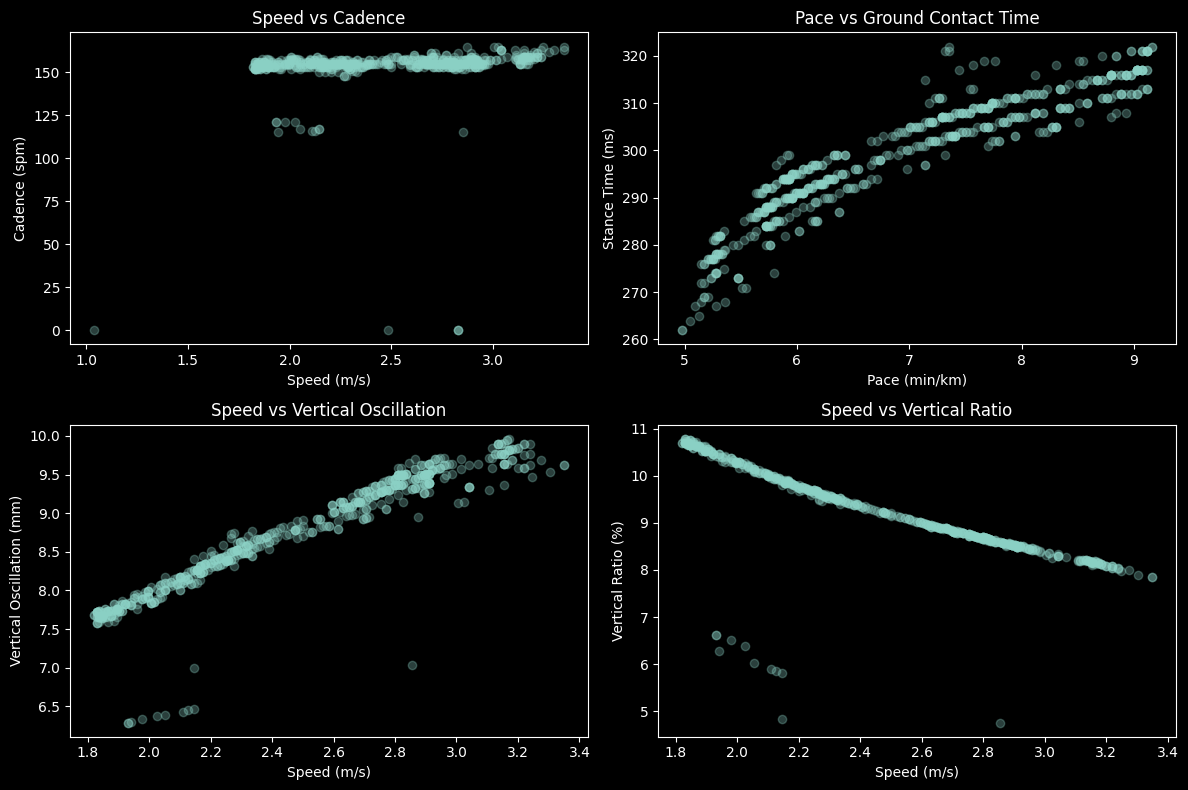

In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2,2, figsize=(12,8))

axes[0,0].scatter(session_records['speed_ms'], session_records['cadence'], alpha=0.3)
axes[0,0].set_xlabel('Speed (m/s)')
axes[0,0].set_ylabel('Cadence (spm)')
axes[0,0].set_title('Speed vs Cadence')

axes[0,1].scatter(session_records['pace_min_km'], session_records['stance_time'], alpha=0.3)
axes[0,1].set_xlabel('Pace (min/km)')
axes[0,1].set_ylabel('Stance Time (ms)')
axes[0,1].set_title('Pace vs Ground Contact Time')

axes[1,0].scatter(session_records['speed_ms'],session_records['vertical_oscillation'], alpha=0.3)
axes[1,0].set_xlabel('Speed (m/s)')
axes[1,0].set_ylabel('Vertical Oscillation (mm)')
axes[1,0].set_title('Speed vs Vertical Oscillation')

axes[1,1].scatter(session_records['speed_ms'],session_records['vertical_ratio'], alpha=0.3)
axes[1,1].set_xlabel('Speed (m/s)')
axes[1,1].set_ylabel('Vertical Ratio (%)')
axes[1,1].set_title('Speed vs Vertical Ratio')

plt.tight_layout()
plt.show()


Let's do the same for all the runs to see if we notice any patterns.

In [25]:
import os

output_dir = '../data/biomechanics_plots_Vlad'
os.makedirs(output_dir, exist_ok=True)

for sid in run_ids:
    session_records = run_records[run_records['session_id'] == sid]
    session_info = runs[runs['session_id'] == sid].iloc[0]
    date = session_info['date'].strftime('%Y-%m-%d')

    fig, axes = plt.subplots(2,2, figsize=(12,8))
    fig.suptitle(f' Run {sid} - {date}')

    axes[0,0].scatter(session_records['speed_ms'], session_records['cadence'], alpha=0.3)
    axes[0,0].set_xlabel('Speed (m/s)')
    axes[0,0].set_ylabel('Cadence (spm)')
    axes[0,0].set_title('Speed vs Cadence')

    axes[0,1].scatter(session_records['pace_min_km'], session_records['stance_time'], alpha=0.3)
    axes[0,1].set_xlabel('Pace (min/km)')
    axes[0,1].set_ylabel('Stance Time (ms)')
    axes[0,1].set_title('Pace vs Ground Contact Time')

    axes[1,0].scatter(session_records['speed_ms'],session_records['vertical_oscillation'], alpha=0.3)
    axes[1,0].set_xlabel('Speed (m/s)')
    axes[1,0].set_ylabel('Vertical Oscillation (mm)')
    axes[1,0].set_title('Speed vs Vertical Oscillation')

    axes[1,1].scatter(session_records['speed_ms'],session_records['vertical_ratio'], alpha=0.3)
    axes[1,1].set_xlabel('Speed (m/s)')
    axes[1,1].set_ylabel('Vertical Ratio (%)')
    axes[1,1].set_title('Speed vs Vertical Ratio')

    plt.tight_layout()
    plt.savefig(f'{output_dir}/run_{sid}_{date}.png')
    plt.close()
    print(f'Saved plot for run {sid} and date {date}')

print('done')

Saved plot for run 34 and date 2026-03-10
Saved plot for run 17 and date 2026-03-18
Saved plot for run 20 and date 2026-03-23
Saved plot for run 13 and date 2026-04-07
Saved plot for run 19 and date 2026-04-10
done
